In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
df = pd.read_csv(r"C:\Users\Jinugu Pallavi\OneDrive\Desktop\summer data science\project3\Superstore.csv", encoding='latin1')

print(df.head())


   csvbase_row_id  ï»¿Row ID        Order ID  Order Date   Ship Date  \
0               1          1  CA-2016-152156  2016-11-08  2016-11-11   
1               2          2  CA-2016-152156  2016-11-08  2016-11-11   
2               3          3  CA-2016-138688  2016-06-12  2016-06-16   
3               4          4  US-2015-108966  2015-10-11  2015-10-18   
4               5          5  US-2015-108966  2015-10-11  2015-10-18   

        Ship Mode Customer ID    Customer Name    Segment        Country  ...  \
0    Second Class    CG-12520      Claire Gute   Consumer  United States  ...   
1    Second Class    CG-12520      Claire Gute   Consumer  United States  ...   
2    Second Class    DV-13045  Darrin Van Huff  Corporate  United States  ...   
3  Standard Class    SO-20335   Sean O'Donnell   Consumer  United States  ...   
4  Standard Class    SO-20335   Sean O'Donnell   Consumer  United States  ...   

  Postal Code Region       Product ID         Category Sub-Category  \
0       4

In [8]:
print(df.columns)

Index(['csvbase_row_id', 'ï»¿Row ID', 'Order ID', 'Order Date', 'Ship Date',
       'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country',
       'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')


In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df = df[['Order Date', 'Sales']]
df.dropna(inplace=True)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  9994 non-null   datetime64[us]
 1   Sales       9994 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 156.3 KB
None


In [10]:
df = df.sort_values('Order Date')

df['Days'] = (df['Order Date'] - df['Order Date'].min()).dt.days

In [11]:
X = df[['Days']]
y = df['Sales']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
y_pred = model.predict(X_test)

In [15]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 263.6001524368298
R2 Score: -0.00013418056483005536


In [16]:
#Forecast Next 30 Days

future_days = np.arange(
    df['Days'].max()+1,
    df['Days'].max()+31
).reshape(-1,1)

future_sales = model.predict(future_days)

forecast = pd.DataFrame({
    'Future_Day': future_days.flatten(),
    'Predicted_Sales': future_sales
})

print(forecast.head())

   Future_Day  Predicted_Sales
0        1458       229.759010
1        1459       229.754961
2        1460       229.750912
3        1461       229.746863
4        1462       229.742814


C:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


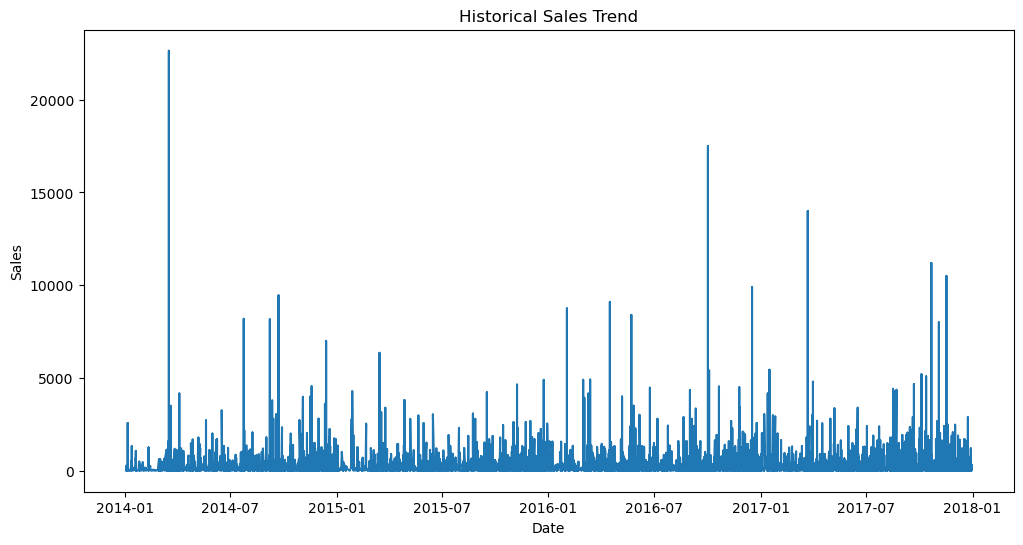

In [17]:
plt.figure(figsize=(12,6))

plt.plot(df['Order Date'], df['Sales'])

plt.title("Historical Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

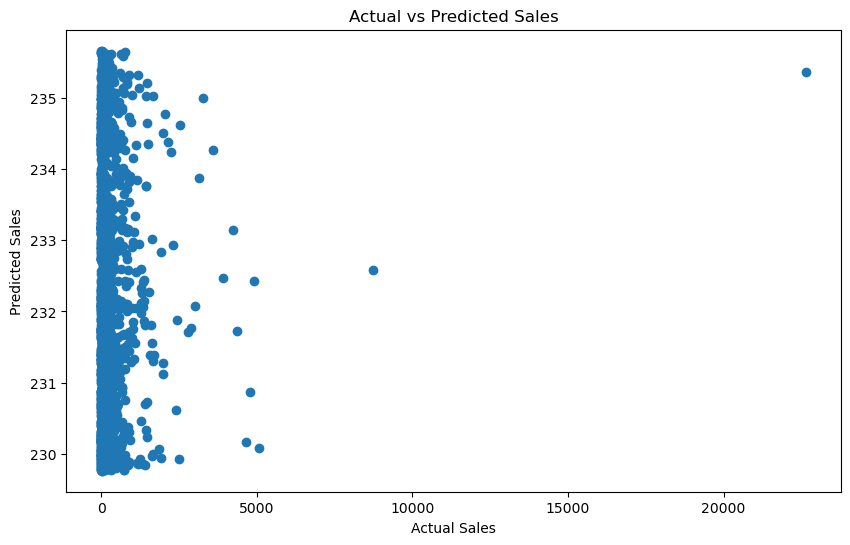

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()


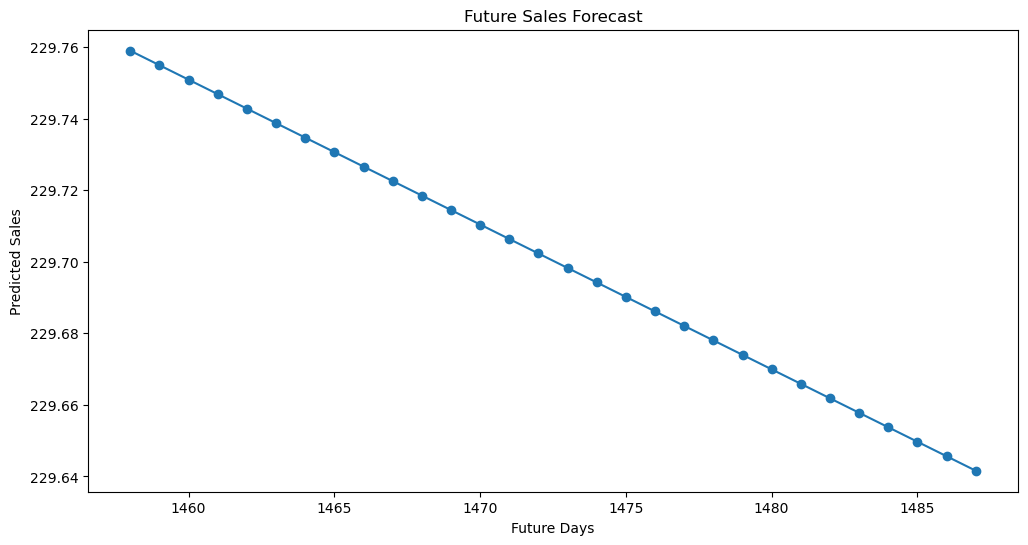

In [20]:
# future forecast"
plt.figure(figsize=(12,6))

plt.plot(
    future_days,
    future_sales,
    marker='o'
)

plt.title("Future Sales Forecast")
plt.xlabel("Future Days")
plt.ylabel("Predicted Sales")

plt.show()